# PA2 Random forests
## Group 38

**Group Members:**
 - Sezin Kokum Mutludogan
 - Priyanka Machchhar 

## Task 1: Working with a dataset with categorical features

#### Step 1. Reading the data

We used pandas library to read the training and test data from the csv files and shuffled the data. We printed the first five rows of the shuffled training data.

In [53]:
import pandas as pd

df_train = pd.read_csv('adult_train.csv')
df_test = pd.read_csv('adult_test.csv')

df_train_shuffled = df_train.sample(frac=1.0, random_state=0)
df_test_shuffled = df_test.sample(frac=1.0, random_state=0)

df_train_shuffled.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,target
22278,49,Local-gov,HS-grad,9,Married-civ-spouse,Transport-moving,Husband,White,Male,0,0,40,United-States,<=50K
8950,49,Private,HS-grad,9,Divorced,Other-service,Not-in-family,Black,Female,0,0,40,United-States,<=50K
7838,31,Private,Prof-school,15,Never-married,Prof-specialty,Not-in-family,White,Male,0,0,50,United-States,<=50K
16505,53,Private,Some-college,10,Divorced,Adm-clerical,Not-in-family,White,Female,0,0,43,United-States,<=50K
19140,30,Private,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,40,United-States,>50K


We splitted the data to X and Y. The column target became y for train and test data. The other columns became X.

In [62]:
X_train = df_train_shuffled.drop('target', axis=1)
y_train = df_train_shuffled['target']

X_test = df_test_shuffled.drop('target', axis=1)
y_test = df_test_shuffled['target']

#### Step 2: Encoding the features as numbers.

We converted the training DataFrame to a list of dictionaries by using to_dict('records'). Then defined a DictVectorizer() object and used .fit_transform() method of it with the list of dictionaries to apply one-hot encoding to the categorical features.

In [55]:
from sklearn.feature_extraction import DictVectorizer

dicts_for_train_data = X_train.to_dict('records')

dv = DictVectorizer()
X_train_encoded = dv.fit_transform(dicts_for_train_data)

We printed the new features for better understanding. We saw that it has created new columns for each class in categorical features.

In [56]:
print(dv.get_feature_names_out())

['age' 'capital-gain' 'capital-loss' 'education-num' 'education=10th'
 'education=11th' 'education=12th' 'education=1st-4th' 'education=5th-6th'
 'education=7th-8th' 'education=9th' 'education=Assoc-acdm'
 'education=Assoc-voc' 'education=Bachelors' 'education=Doctorate'
 'education=HS-grad' 'education=Masters' 'education=Preschool'
 'education=Prof-school' 'education=Some-college' 'hours-per-week'
 'marital-status=Divorced' 'marital-status=Married-AF-spouse'
 'marital-status=Married-civ-spouse'
 'marital-status=Married-spouse-absent' 'marital-status=Never-married'
 'marital-status=Separated' 'marital-status=Widowed' 'native-country=?'
 'native-country=Cambodia' 'native-country=Canada' 'native-country=China'
 'native-country=Columbia' 'native-country=Cuba'
 'native-country=Dominican-Republic' 'native-country=Ecuador'
 'native-country=El-Salvador' 'native-country=England'
 'native-country=France' 'native-country=Germany' 'native-country=Greece'
 'native-country=Guatemala' 'native-countr

Below two cells, we printed the first sample of the list of dictionaries and one-hot encoded data to see their representations.

In [57]:
print(dicts_for_train_data[0])

{'age': 49, 'workclass': 'Local-gov', 'education': 'HS-grad', 'education-num': 9, 'marital-status': 'Married-civ-spouse', 'occupation': 'Transport-moving', 'relationship': 'Husband', 'race': 'White', 'sex': 'Male', 'capital-gain': 0, 'capital-loss': 0, 'hours-per-week': 40, 'native-country': 'United-States'}


In [58]:
print(X_train_encoded[0])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 13 stored elements and shape (1, 107)>
  Coords	Values
  (0, 0)	49.0
  (0, 1)	0.0
  (0, 2)	0.0
  (0, 3)	9.0
  (0, 15)	1.0
  (0, 20)	40.0
  (0, 23)	1.0
  (0, 67)	1.0
  (0, 84)	1.0
  (0, 89)	1.0
  (0, 90)	1.0
  (0, 97)	1.0
  (0, 100)	1.0


In Programming Assignment 1, we got best results with Gradient Boosting Classifier. We used this model again to calculate cross-validation on the encoded train data. We got 86.56% accuracy.

In [59]:
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import GradientBoostingClassifier

print(f"Cross Validation Accuracy: {cross_val_score(GradientBoostingClassifier(), X_train_encoded, y_train).mean()}")

Cross Validation Accuracy: 0.865636879708736


We applied the same encoding to the test dataset.

In [60]:
dicts_for_test_data = X_test.to_dict('records')
X_test_encoded = dv.transform(dicts_for_test_data)

We trained the Gradient Boosting Classifier and calculated its accuracy on the test data. We got 87.11% test accuracy.

In [63]:
from sklearn.metrics import accuracy_score

clf = GradientBoostingClassifier()
clf.fit(X_train_encoded, y_train)
y_guess = clf.predict(X_test_encoded)
print(f"Test accuracy: {accuracy_score(y_test, y_guess)}")

Test accuracy: 0.8711381364781033


#### Step 3. Combining the steps.

We created a pipeline with DictVectorizer and GradientBoostClassifier. We trained the model by using fit function of the pipeline and then made predictions with the predict function. We checked the test accuracy to see if the pipeline is working. We got the same accuracy as before, thus we validated that the pipeline is working.

In [64]:
from sklearn.pipeline import make_pipeline

pipeline = make_pipeline(
  DictVectorizer(),
  GradientBoostingClassifier()
)

In [65]:
pipeline.fit(dicts_for_train_data, y_train)
y_pred = pipeline.predict(dicts_for_test_data)
print(f"Test accuracy: {accuracy_score(y_test, y_pred)}")

Test accuracy: 0.8711381364781033


## Task 2: Decision trees and random forests

#### Underfitting and overfitting in decision tree classifiers.

We trained a Decision Tree Classifier with the new data. We used cross-validation on training set and accuracy on test set as the evaluation metrics. We used different max_depth values between 1 and 22. In Programming Assignment 1 we took up to 12, but in this assignment we decided to try up to 22 to see the split better. We saw a similar effect in the plot as in the Programming Assignment 1 which indicates overfitting. Both training and test accuracy were increased up to some point. After this point, the test accuracy started to decrease while the training accuracy increased.

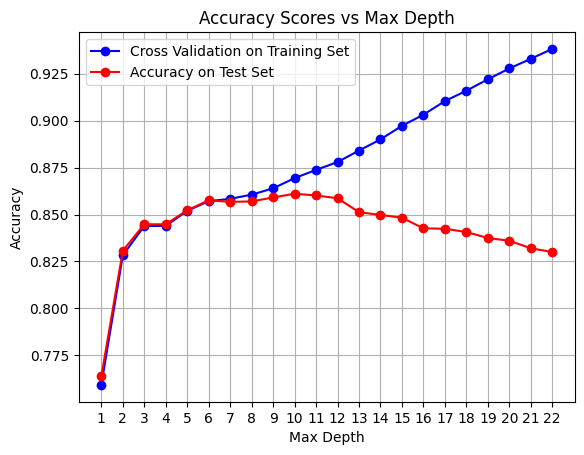

In [70]:
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

train_scores = []
test_scores = []
max_depth = 23

for i in range(1, max_depth):
    pipeline = make_pipeline(
      DictVectorizer(),
      DecisionTreeClassifier(max_depth=i)
    )
    pipeline.fit(dicts_for_train_data, y_train)
    train_score = accuracy_score(y_train, pipeline.predict(dicts_for_train_data))
    test_score = accuracy_score(y_test, pipeline.predict(dicts_for_test_data))

    train_scores.append(train_score)
    test_scores.append(test_score)

plt.plot(list(range(1, max_depth)), train_scores, marker='o', linestyle='-', color='b', label='Cross Validation on Training Set')
plt.plot(list(range(1, max_depth)), test_scores, marker='o', linestyle='-', color='r', label='Accuracy on Test Set')

plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Accuracy Scores vs Max Depth')
plt.xticks(list(range(1, max_depth)))
plt.grid(True)
plt.legend()
plt.show()

#### Underfitting and overfitting in random forest classifiers.

For the Random Forest Classifier, we used max_depth between 1 and 22 as we did for the Decision Tree Classifier. For ensemble size, we used powers of 2 from 1 to 512 and plotted the results for each value. Again, we saw a similar overfit effect for all ensemble sizes, but better mitigated with higher ensemble size.

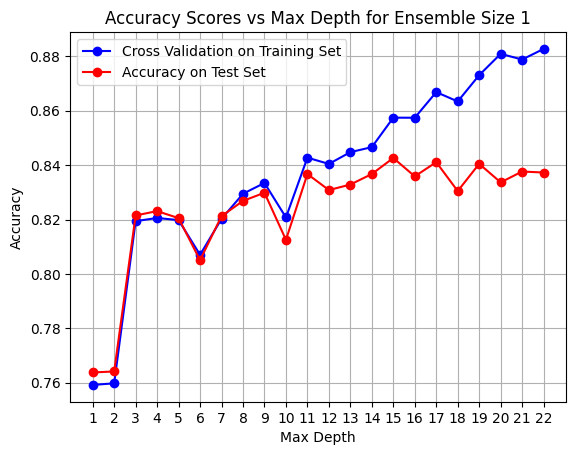

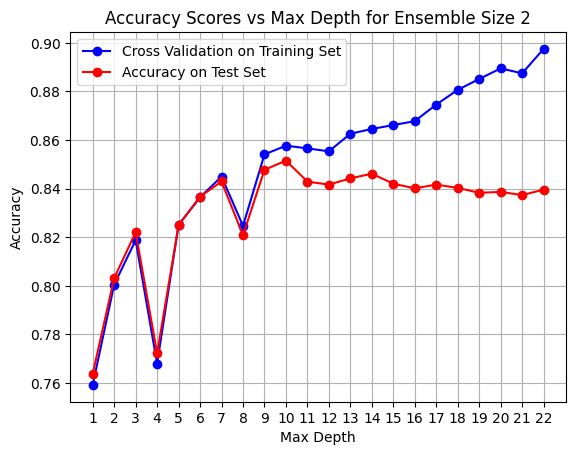

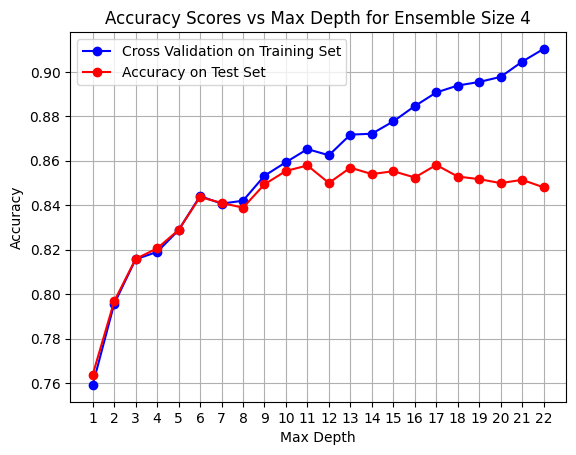

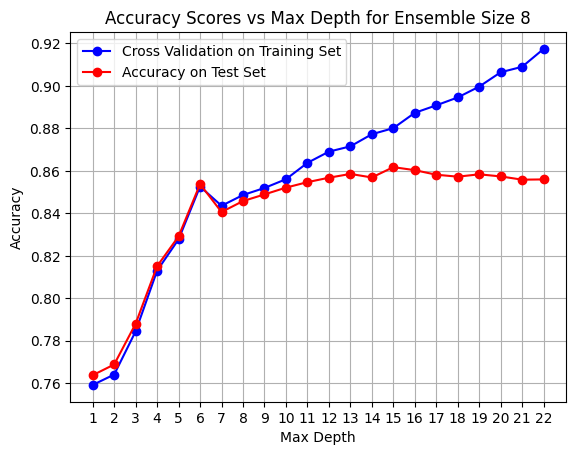

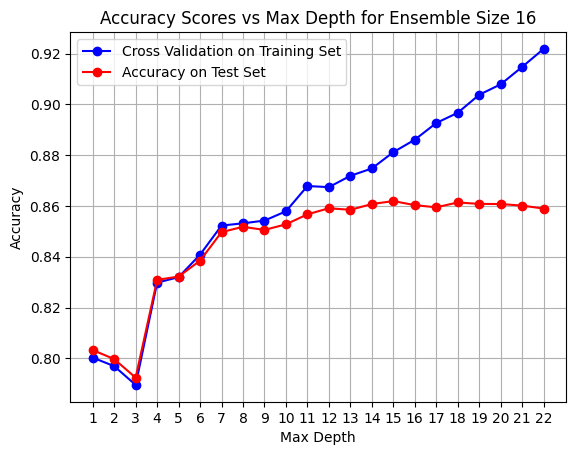

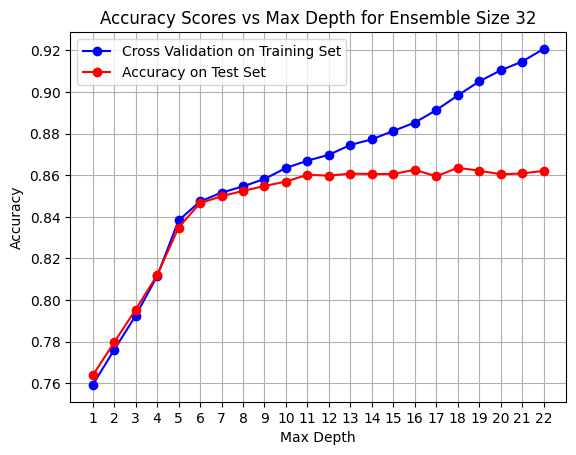

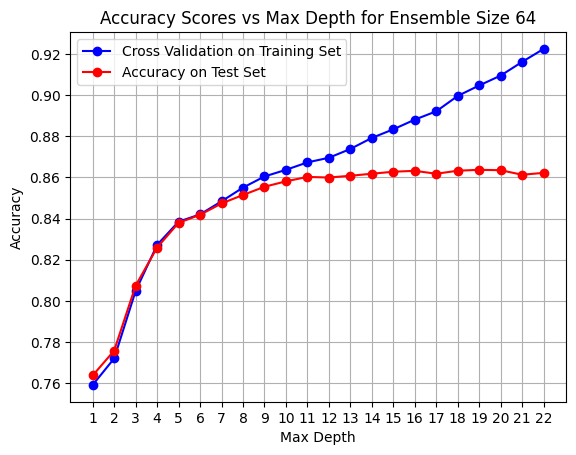

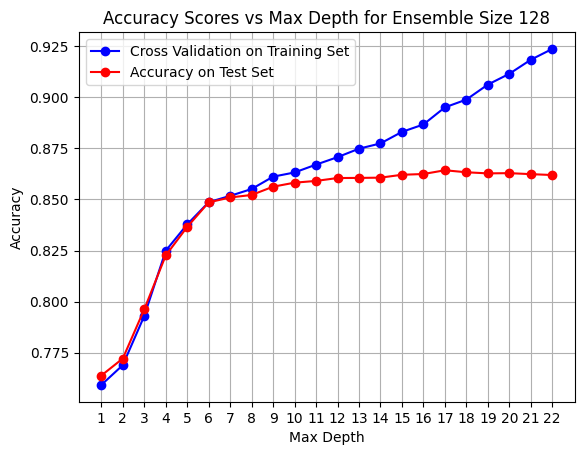

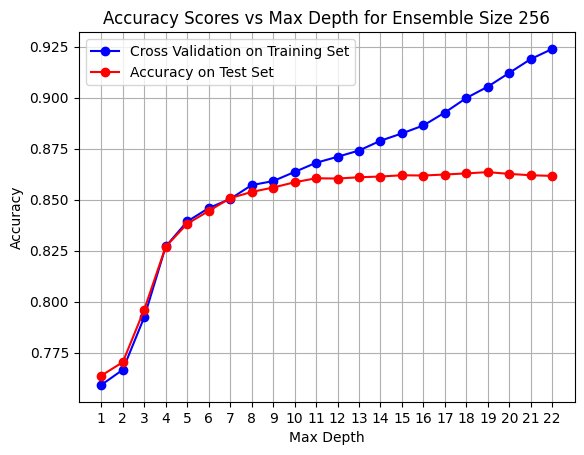

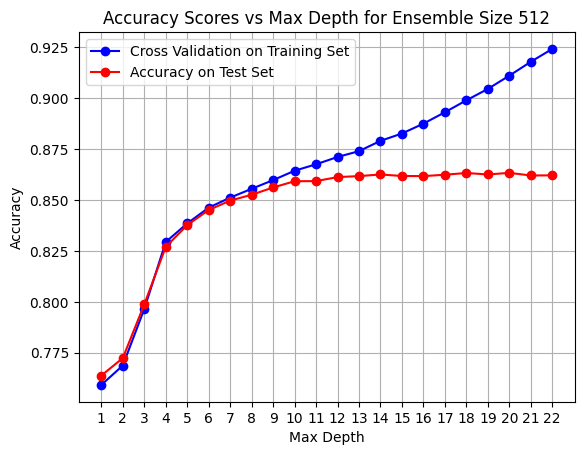

In [78]:
from sklearn.ensemble import RandomForestClassifier
import datetime

max_depth = 23
max_ensemble_power = 10
best_test_accuracies = {}
longest_training_times = {}

for i in range(max_ensemble_power):
    train_scores = []
    test_scores = []
    best_test_accuracy = 0
    longest_training_time = datetime.timedelta.min

    for j in range(1, max_depth):
        pipeline = make_pipeline(
          DictVectorizer(),
          RandomForestClassifier(n_estimators=2**i, max_depth=j, n_jobs=-1)
        )

        start_time = datetime.datetime.now()
        pipeline.fit(dicts_for_train_data, y_train)
        training_time = datetime.datetime.now() - start_time
        if training_time > longest_training_time:
            longest_training_time = training_time

        train_score = accuracy_score(y_train, pipeline.predict(dicts_for_train_data))
        test_score = accuracy_score(y_test, pipeline.predict(dicts_for_test_data))

        if test_score > best_test_accuracy:
            best_test_accuracy = test_score

        train_scores.append(train_score)
        test_scores.append(test_score)

    best_test_accuracies[2**i] = best_test_accuracy
    longest_training_times[2**i] = int(longest_training_time.total_seconds() * 1000)

    plt.plot(list(range(1, max_depth)), train_scores, marker='o', linestyle='-', color='b', label='Cross Validation on Training Set')
    plt.plot(list(range(1, max_depth)), test_scores, marker='o', linestyle='-', color='r', label='Accuracy on Test Set')

    plt.xlabel('Max Depth')
    plt.ylabel('Accuracy')
    plt.title(f'Accuracy Scores vs Max Depth for Ensemble Size {2**i}')
    plt.xticks(list(range(1, max_depth)))
    plt.grid(True)
    plt.legend()
    plt.show()

Below, we printed the best accuracy and longest training time for each ensemble size to be used in the discussion.

In [101]:
for i in range(max_ensemble_power):
    index = 2**i
    print(f"Ensemble Size: {index}, Accuracy: {best_test_accuracies[index]*100:.2f}%, Training Time: {longest_training_times[index]} ms")

Ensemble Size: 1, Accuracy: 84.26%, Training Time: 165 ms
Ensemble Size: 2, Accuracy: 85.15%, Training Time: 165 ms
Ensemble Size: 4, Accuracy: 85.81%, Training Time: 177 ms
Ensemble Size: 8, Accuracy: 86.17%, Training Time: 190 ms
Ensemble Size: 16, Accuracy: 86.19%, Training Time: 251 ms
Ensemble Size: 32, Accuracy: 86.36%, Training Time: 364 ms
Ensemble Size: 64, Accuracy: 86.37%, Training Time: 594 ms
Ensemble Size: 128, Accuracy: 86.43%, Training Time: 1072 ms
Ensemble Size: 256, Accuracy: 86.35%, Training Time: 2034 ms
Ensemble Size: 512, Accuracy: 86.33%, Training Time: 4111 ms


#### Discussion

- The curve of Decision Tree Classifier is smoother when compared to Random Forest Classifier's curve. Even though, Decision Tree Classifier and Random Forest Classifier with ensemble size 1 are almost the same models, the bootstrap parameter of Random Forest Classifier seems to cause that fluctuations. It uses random subset of the dataset while Decision Tree Classifier uses the whole dataset.
- As the ensemble size grows, the curve gets smoother for random forests.
- At the beginning, the best observed test set accuracy increases as the ensemble size grows. It reaches the top point with ensemble size 128. Then it doesn't improve anymore. It's probably because the model has already captured most of the patterns.
- The training time increases almost linearly with the ensemble size.

## Task 3: Feature importances in random forest classifiers

We created a pipeline with Random Forest Classifier by using ensemble size 128 and max_depth 17 and trained it with the training data.

In [82]:
pipeline = make_pipeline(
  DictVectorizer(),
  RandomForestClassifier(n_estimators=128, max_depth=17, n_jobs=-1)
)

pipeline.fit(dicts_for_train_data, y_train)

Pipeline(steps=[('dictvectorizer', DictVectorizer()),
                ('randomforestclassifier',
                 RandomForestClassifier(max_depth=17, n_estimators=128,
                                        n_jobs=-1))])

We created a dictionary as feature names are the keys and their importances are the values. Then we sorted this dict in the descending order by importance values and printed below. When we inspect the first few features:

- **capital-gain:** People who earn above 50k are likely to have more investments and gain more from those investments. This is why capital-gain is the most important feature for this dataset.
- **marital-status=Married-civ-spouse:** This is a one-hot encoded feature. Even though they are not on the top, relationship=Husband and relationship=Wife are also among the important features. So, that shows marital-status affects the income.
- **education-num:** Education level and income are generally in correlation.
- **age:** Experience increases with age, which leads to a higher income.
- **hours-per-week:** The people who work for more hours per week earn more money.

In [99]:
feature_importances = dict(zip(pipeline.steps[0][1].feature_names_,\
                               [float(np_importance) for np_importance in pipeline.steps[1][1].feature_importances_]))
feature_importances = dict(sorted(feature_importances.items(), key=lambda x: x[1], reverse=True))

for key, value in feature_importances.items():
    print(f"{key:50}{value:.10f}")

capital-gain                                      0.1541693155
marital-status=Married-civ-spouse                 0.1230296666
education-num                                     0.0934836021
age                                               0.0894301499
hours-per-week                                    0.0615394241
relationship=Husband                              0.0568686172
marital-status=Never-married                      0.0447217335
capital-loss                                      0.0402718122
occupation=Exec-managerial                        0.0253780375
occupation=Prof-specialty                         0.0209536209
education=Bachelors                               0.0196416450
relationship=Wife                                 0.0181155796
relationship=Not-in-family                        0.0174566915
sex=Male                                          0.0170522837
sex=Female                                        0.0150672905
relationship=Own-child                            0.015

In the previous study period, we took Introduction to Data Science & AI course. During that course, we used Principal Component Analysis method to dimensionality reduction. It was relying on eigenvectors and eigenvalues of feature covariance matrix. It was finding the features which has the most influence in the dataset. Even though, it's unsupervised and not find direct relation to the target value, maybe a hybrid aprroach can be developed which will also consider the target value.

In the paper, the authors discussed about permutation importance and drop-column importance methods.